In [1]:
import os
import json
import cv2
import matplotlib.pyplot as plt

Shape: (224, 224, 3)


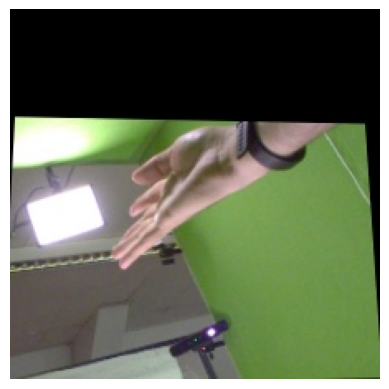

In [2]:
img_path = "../data/training/rgb/00000000.jpg"

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Shape:", image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

In [3]:
with open("../data/training_xyz.json", "r") as f:
    xyz_data = json.load(f)

print("Type:", type(xyz_data))
print("Antall samples:", len(xyz_data))
print("Første element:\n", xyz_data[0])

Type: <class 'list'>
Antall samples: 32560
Første element:
 [[0.029402047395706177, -0.027920207008719444, 0.5870807766914368], [0.005140833556652069, -0.044145505875349045, 0.6141912341117859], [-0.010067682713270187, -0.045154400169849396, 0.6402467489242554], [-0.02945629134774208, -0.03155030310153961, 0.6546691656112671], [-0.05713975429534912, -0.013767082244157791, 0.6731467247009277], [-0.017500750720500946, -0.01142771914601326, 0.66874760389328], [-0.03550991043448448, -0.0002552643418312073, 0.6965733766555786], [-0.05062461644411087, 0.007310394197702408, 0.7137471437454224], [-0.06246119365096092, 0.019727960228919983, 0.7355319261550903], [-0.025251295417547226, 0.012166790664196014, 0.661927342414856], [-0.044636860489845276, 0.028589684516191483, 0.6841884255409241], [-0.06037726253271103, 0.04087386652827263, 0.6991667151451111], [-0.07048986852169037, 0.059277135878801346, 0.7184633016586304], [-0.026956938207149506, 0.024798300117254257, 0.6373963952064514], [-0.0451

In [4]:
with open("../data/training_K.json", "r") as f:
    K_data = json.load(f)

print("Type:", type(K_data))
print("Antall samples:", len(K_data))
print("Første element:\n", K_data[0])

Type: <class 'list'>
Antall samples: 32560
Første element:
 [[388.9018310596544, 0.0, 112.0], [0.0, 388.71231836584275, 112.0], [0.0, 0.0, 1.0]]


In [5]:
import numpy as np

xyz = np.array(xyz_data[0])   # shape: (21, 3)
K = np.array(K_data[0])       # shape: (3, 3)

fx = K[0, 0]
fy = K[1, 1]
cx = K[0, 2]
cy = K[1, 2]

X = xyz[:, 0]
Y = xyz[:, 1]
Z = xyz[:, 2]

u = fx * X / Z + cx
v = fy * Y / Z + cy

uv = np.stack([u, v], axis=1)

print("Shape:", uv.shape)
print(uv[:5])

Shape: (21, 2)
[[131.47689402  93.51373912]
 [115.25514184  84.06097876]
 [105.88463862  84.58545771]
 [ 94.5016875   93.26688699]
 [ 78.98824453 104.05012182]]


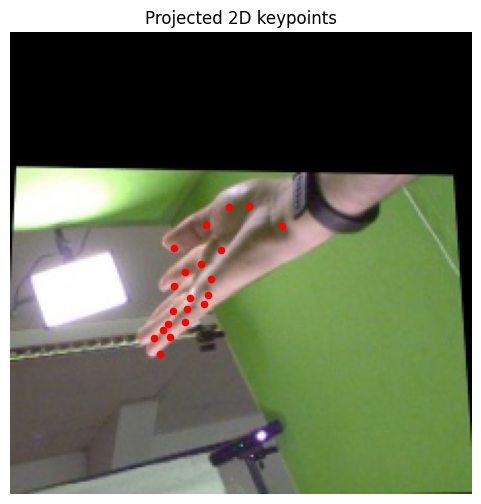

In [6]:
plt.figure(figsize=(6, 6))
plt.imshow(image)

for x, y in uv:
    plt.scatter(x, y, c="red", s=20)

plt.title("Projected 2D keypoints")
plt.axis("off")
plt.show()